# 04 · YouTubers × Instagram

Built on `polarization.py`. Writes `user_counts.csv`, `channel_df.csv`, `video_df.csv`.

Only 72 of 210 influencers have an Instagram link (27 left / 45 right), so this is the thinnest of the four cells.

In [1]:
import sys
sys.path.append(".")          # polarization.py sits next to this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import polarization as P

In [2]:
from pathlib import Path

ROOT = Path("dataset")

In [3]:
PLATFORM      = "Instagram"
PRODUCER_TYPE = "YouTuber"

OUT = ROOT / "influencers" / "instagram"

## 1. Load comments

In [ ]:
df = P.flatten_instagram_comments(
    ROOT / "influencers" / "instagram" / "scraped_posts_merged.json",
    ROOT / "influencers" / "instagram" / "scraped_comments_merged.json",
)

print(df.shape)
df.head()

  591,243 rows -> 220 MB in memory
(591243, 12)


,video_id,video_title,channel_id,channel_name,channel_url,post_timestamp,comment_id,parent_id,type,author,like_count,timestamp
0,DUHtpF7jo-w,This weekend!!! 🔥🔥🔥\n🎬 <12.3 The Day> North Am...,77093089825,kai.us_official,https://www.instagram.com/jeonhangil/,2026-01-30T03:56:05.000Z,18170911369391467,None,comment,lovely_joannek,62,2026-01-30T04:52:11.000Z
1,DUHtpF7jo-w,This weekend!!! 🔥🔥🔥\n🎬 <12.3 The Day> North Am...,77093089825,kai.us_official,https://www.instagram.com/jeonhangil/,2026-01-30T03:56:05.000Z,18067467968197707,18170911369391467,reply,kai.us_official,17,2026-01-30T05:36:53.000Z
2,DUHtpF7jo-w,This weekend!!! 🔥🔥🔥\n🎬 <12.3 The Day> North Am...,77093089825,kai.us_official,https://www.instagram.com/jeonhangil/,2026-01-30T03:56:05.000Z,18094602707298725,None,comment,soy.nov,8,2026-01-30T13:27:45.000Z
3,DUHtpF7jo-w,This weekend!!! 🔥🔥🔥\n🎬 <12.3 The Day> North Am...,77093089825,kai.us_official,https://www.instagram.com/jeonhangil/,2026-01-30T03:56:05.000Z,18559275688030065,None,comment,dios_980204,25,2026-02-07T13:41:31.000Z
4,DUHtpF7jo-w,This weekend!!! 🔥🔥🔥\n🎬 <12.3 The Day> North Am...,77093089825,kai.us_official,https://www.instagram.com/jeonhangil/,2026-01-30T03:56:05.000Z,18098395552931125,None,comment,80yun77,8,2026-02-08T01:26:50.000Z


In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Earliest:", df["timestamp"].min())
print("Latest:", df["timestamp"].max())

Earliest: 2014-08-03 23:31:36+00:00
Latest: 2026-05-27 07:51:38+00:00


In [5]:
summary = pd.DataFrame({
    "Total": [
        df["channel_id"].nunique(),
        df["video_id"].nunique(),
        df["comment_id"].nunique(),
        df["author"].nunique()
    ]
}, index=[
    "Channels",
    "Videos",
    "Comments",
    "Users"
])

summary

,Total
Channels,94
Videos,12923
Comments,591092
Users,166533


In [5]:
df["type"].value_counts()

type
comment    590908
reply         335
Name: count, dtype: int64

## 2. Ideology lookup

In [6]:
ideo = P.youtuber_ideology(
    "D:/School/2026 Spring/KR_Polarization/dataset/Influencer_YouTube.xlsx",
    PLATFORM,
    url_col="Instagram Link",      # note: different column from cell 03
    name_col="Channel",
    stance_col="Stance",
)

ideo.head()

  dropping 12 rows with unusable stance: {'nan'}
  ideology map (Instagram): 72 producers -> {'right': 45, 'left': 27}


,key,producer_name,ideology
0,hover_lab,가로세로연구소,right
1,gamdonglantv4.0,감동란,right
3,kang__yongseok,강용석의 인싸it,right
4,ko_non21,고논,right
6,drgongbh,공병호,right


In [7]:
ideo["ideology"].value_counts()

ideology
right    45
left     27
Name: count, dtype: int64

## 3. Prepare

Dedupe on `comment_id`, attach ideology, drop producer self-comments, fold
`independent` into left. Read the printout: a low match rate means the lookup
keys don't line up, and a big drop at the dedupe step means the source file
holds each record more than once.

In [7]:
prepared = P.prepare(df, ideo, PLATFORM)

  dedupe on comment_id: 591,243 -> 591,092
  ideology matched: 588,226 / 591,092 (99.5%)
  top unmatched producers:
    kai.us_official: 573
    tarasis__: 442
    seoulpyongyangcouple: 404
    econ_mind_2: 402
    thekangminlee: 160
  self-comments dropped: 2,433


In [9]:
instagram_summary = {
    "Producers/Channels": prepared["channel_id"].nunique(),
    "Instagram posts": prepared["video_id"].nunique(),
    "Instagram comments": prepared["comment_id"].nunique(),
}

instagram_summary

{'Producers/Channels': 72,
 'Instagram posts': 12688,
 'Instagram comments': 585793}

## 4. User-level measures

In [9]:
uc_5, _ = P.user_measures(prepared, min_comments=5)
uc_10, _ = P.user_measures(prepared, min_comments=10)
uc_20, _ = P.user_measures(prepared, min_comments=20)

  authors: 165,388 | active (>=5): 25,197 | comments kept: 377,358
  users on >1 producer: 16,544 / 25,197 (65.7%)
  authors: 165,388 | active (>=10): 11,340 | comments kept: 288,060
  users on >1 producer: 8,726 / 11,340 (76.9%)
  authors: 165,388 | active (>=20): 4,550 | comments kept: 197,355
  users on >1 producer: 3,862 / 4,550 (84.9%)


In [10]:
for threshold, uc in [
    (5, uc_5),
    (10, uc_10),
    (20, uc_20)
]:
    # Add labels
    uc["producer_type"] = PRODUCER_TYPE
    uc["platform"] = PLATFORM

    # Verify labels
    pt = set(uc["producer_type"])
    pl = set(uc["platform"])

    assert pt == {PRODUCER_TYPE}
    assert pl == {PLATFORM}

    # Save
    uc.to_csv(
        f"{OUT}/user_counts_{threshold}.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"user_counts_{threshold}: "
        f"{len(uc):,} users | {pt} | {pl} | saved"
    )

user_counts_5: 25,197 users | {'YouTuber'} | {'Instagram'} | saved
user_counts_10: 11,340 users | {'YouTuber'} | {'Instagram'} | saved
user_counts_20: 4,550 users | {'YouTuber'} | {'Instagram'} | saved


In [14]:
user_counts, comment_users = P.user_measures(prepared, min_comments=P.MIN_COMMENTS)

user_counts = P.tag(user_counts, PLATFORM, PRODUCER_TYPE)
user_counts.head()

  authors: 165,388 | active (>=20): 4,550 | comments kept: 197,355
  users on >1 producer: 3,862 / 4,550 (84.9%)


,author,left,right,user_bias,user_cross_cut,total,n_producers,activity_band,platform,producer_type
0,0.suee,34,2,-0.888889,0.209877,36,4,20–49,Instagram,YouTuber
1,000100sin,0,58,1.000000,0.000000,58,7,50–99,Instagram,YouTuber
2,00821j7ty,50,0,-1.000000,0.000000,50,2,50–99,Instagram,YouTuber
3,008373661s,0,23,1.000000,0.000000,23,3,20–49,Instagram,YouTuber
4,00yesmi00,44,0,-1.000000,0.000000,44,4,20–49,Instagram,YouTuber


In [17]:
instagram_summary = {
    "Producers/Channels": comment_users["channel_id"].nunique(),
    "Instagram posts": comment_users["video_id"].nunique(),
    "Instagram comments": comment_users["comment_id"].nunique(),
}

instagram_summary

{'Producers/Channels': 68,
 'Instagram posts': 11052,
 'Instagram comments': 197355}

In [10]:
user_counts[["user_bias", "user_cross_cut", "total", "n_producers"]].describe()

,user_bias,user_cross_cut,total,n_producers
count,4550.000000,4550.000000,4550.000000,4550.000000
mean,-0.000284,0.206674,43.374725,4.280879
std,0.890787,0.317496,44.647217,2.530406
min,-1.000000,0.000000,20.000000,1.000000
25%,-1.000000,0.000000,24.000000,2.000000
50%,0.066667,0.000000,31.000000,4.000000
75%,1.000000,0.330579,46.000000,6.000000
max,1.000000,1.000000,1318.000000,24.000000


In [18]:
bias_neg1_pct = (user_counts["user_bias"] == -1).mean() * 100
bias_pos1_pct = (user_counts["user_bias"] == 1).mean() * 100

print(f"Bias = -1: {bias_neg1_pct:.2f}%")
print(f"Bias = +1: {bias_pos1_pct:.2f}%")

Bias = -1: 30.51%
Bias = +1: 27.16%


In [19]:
zero_pct = (user_counts["user_cross_cut"] == 0).mean() * 100
positive_pct = (user_counts["user_cross_cut"] > 0).mean() * 100

print(f"Cross-cut = 0: {zero_pct:.2f}%")
print(f"Cross-cut > 0: {positive_pct:.2f}%")

Cross-cut = 0: 57.67%
Cross-cut > 0: 42.33%


### Producers per user

`user_bias` only varies for users who comment across more than one producer.
If this share is low the measure collapses to +/-1 and cross-cutting goes to 0
by construction rather than by finding.

In [11]:
multi = (user_counts["n_producers"] > 1).sum()

print(f"users on >1 producer: {multi:,} / {len(user_counts):,} "
      f"({multi / len(user_counts):.1%})")

user_counts["n_producers"].describe()

users on >1 producer: 3,862 / 4,550 (84.9%)


count    4550.000000
mean        4.280879
std         2.530406
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        24.000000
Name: n_producers, dtype: float64

## 5. Distributions

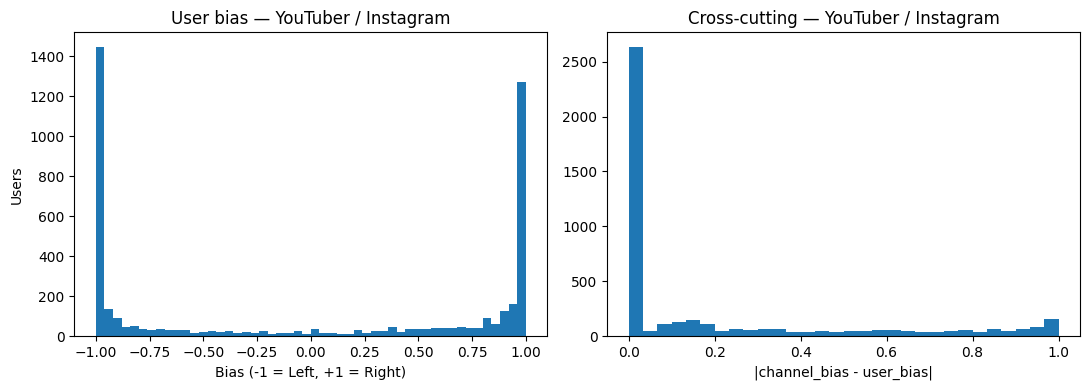

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(user_counts["user_bias"], bins=50)
ax[0].set_title(f"User bias — {PRODUCER_TYPE} / {PLATFORM}")
ax[0].set_xlabel("Bias (-1 = Left, +1 = Right)")
ax[0].set_ylabel("Users")

ax[1].hist(user_counts["user_cross_cut"].dropna(), bins=30)
ax[1].set_title(f"Cross-cutting — {PRODUCER_TYPE} / {PLATFORM}")
ax[1].set_xlabel("|channel_bias - user_bias|")

plt.tight_layout()
plt.show()

### Audience size

`producer_stats.csv` comes from `fetch_audience_size.py` — YouTube subscriber
counts via the Data API, Instagram follower counts via instaloader. If the file
isn't there yet the notebook still runs; `audience_size` is just NaN and the
control drops out of the regressions.

In [13]:
import os

_stats_path = f"{OUT}/producer_stats.csv"

if os.path.exists(_stats_path):
    stats = P.load_producer_stats(_stats_path)
else:
    stats = None
    print("no producer_stats.csv yet -- audience_size will be NaN")

  producer stats: 56 / 72 with a usable count


## 6. Producer- and item-level aggregates

In [14]:
channel_df = P.channel_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)
video_df   = P.video_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)

print("producers:", channel_df.shape)
print("items    :", video_df.shape)

channel_df.head()

  audience_size missing for 15 / 68 rows
  audience_size missing for 3119 / 11052 rows
producers: (68, 14)
items    : (11052, 16)


,key,channel_id,channel_name,producer_name,ideology,channel_url,mean_user_bias,mean_cross_cutting,n_comments,n_users,total_likes,audience_size,platform,producer_type
0,1_jeayoun,5110706,1_jeayoun,고양이뉴스,left,https://www.instagram.com/1_jeayoun/,-0.822014,0.177986,42,12,80,1927.0,Instagram,YouTuber
1,5choun3,70022672556,5choun3,내 이름은 오춘삼,right,https://www.instagram.com/5choun3/,0.699270,0.300730,469,206,26177,25048.0,Instagram,YouTuber
2,_sisafocus,79680276506,_sisafocus,시사포커스,right,https://www.instagram.com/_sisafocus/,0.455912,0.544088,3858,1061,83525,NaN,Instagram,YouTuber
3,agalchoi,74833102173,agalchoi,최현준TV,left,https://www.instagram.com/agalchoi/,-0.868341,0.131659,736,63,2640,10221.0,Instagram,YouTuber
4,aiai26791,73655484612,aiai26791,우팔롬아,right,https://www.instagram.com/aiai26791/,0.819437,0.180563,464,150,12882,NaN,Instagram,YouTuber


In [15]:
df.shape

(591243, 10)

### Label check

All three outputs must carry the same `producer_type` / `platform`. The
previous notebooks wrote `"YouTuber"` into the politician files and
`"Politician"` into the youtuber user counts, which silently flattened the
group comparison in the regressions.

In [16]:
for name, frame in [("user_counts", user_counts),
                    ("channel_df", channel_df),
                    ("video_df", video_df)]:
    pt, pl = set(frame["producer_type"]), set(frame["platform"])
    ok = pt == {PRODUCER_TYPE} and pl == {PLATFORM}
    print(f"{name:12} {pt} {pl} {'OK' if ok else '<<< MISLABELLED'}")
    assert ok, name

user_counts  {'YouTuber'} {'Instagram'} OK
channel_df   {'YouTuber'} {'Instagram'} OK
video_df     {'YouTuber'} {'Instagram'} OK


## 7. Save

In [17]:
user_counts.to_csv(f"{OUT}/user_counts.csv", index=False, encoding="utf-8-sig")
channel_df.to_csv(f"{OUT}/channel_df.csv", index=False, encoding="utf-8-sig")
video_df.to_csv(f"{OUT}/video_df.csv", index=False, encoding="utf-8-sig")

print("saved to", OUT)

saved to D:/School/2026 Spring/KR_Polarization/dataset/influencers/instagram
